In [42]:
import numpy as np
import pandas as pd




In [43]:
cus_df=pd.read_csv('customers.csv')
sales_df=pd.read_csv('sales.csv')

In [44]:
cus_df.head()

,order_id,customer_rating
0,1,1
1,2,1
2,3,2
3,4,1
4,5,4


In [45]:
sales_df.head()

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72


In [46]:
sales_df.shape

(500, 10)

In [47]:
sales_df.columns

Index(['order_id', 'date', 'region', 'product', 'category', 'customer_type',
       'quantity', 'price', 'discount', 'sales'],
      dtype='object')

In [48]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    int64  
 1   date           500 non-null    object 
 2   region         500 non-null    object 
 3   product        500 non-null    object 
 4   category       500 non-null    object 
 5   customer_type  500 non-null    object 
 6   quantity       500 non-null    int64  
 7   price          500 non-null    int64  
 8   discount       500 non-null    float64
 9   sales          500 non-null    float64
dtypes: float64(2), int64(3), object(5)
memory usage: 39.2+ KB


In [49]:
sales_df.customer_type.value_counts()

customer_type
Returning    261
New          239
Name: count, dtype: int64

In [50]:
sales_df.category.value_counts()

category
Electronics    266
Accessories    234
Name: count, dtype: int64

In [51]:
sales_df.isnull().sum()

order_id         0
date             0
region           0
product          0
category         0
customer_type    0
quantity         0
price            0
discount         0
sales            0
dtype: int64

In [52]:
sales_df.duplicated().sum()

np.int64(0)

In [53]:
sales_df.describe(include='all')

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
count,500.000000,500,500,500,500,500,500.000000,500.000000,500.00000,500.000000
unique,NaN,267,4,6,2,2,NaN,NaN,NaN,NaN
top,NaN,2024-04-08,North,Mouse,Electronics,Returning,NaN,NaN,NaN,NaN
freq,NaN,6,151,96,266,261,NaN,NaN,NaN,NaN
mean,250.500000,NaN,NaN,NaN,NaN,NaN,4.968000,768.158000,0.14666,3333.059560
std,144.481833,NaN,NaN,NaN,NaN,NaN,2.569081,404.010497,0.08612,2693.185995
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,50.000000,0.00000,67.320000
25%,125.750000,NaN,NaN,NaN,NaN,NaN,3.000000,432.750000,0.08000,1120.867500
50%,250.500000,NaN,NaN,NaN,NaN,NaN,5.000000,742.000000,0.15000,2582.805000
75%,375.250000,NaN,NaN,NaN,NaN,NaN,7.000000,1094.500000,0.22000,4998.030000


In [54]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   order_id         500 non-null    int64
 1   customer_rating  500 non-null    int64
dtypes: int64(2)
memory usage: 7.9 KB


In [55]:
cus_df.describe(include='all')

,order_id,customer_rating
count,500.000000,500.000000
mean,250.500000,2.480000
std,144.481833,1.118975
min,1.000000,1.000000
25%,125.750000,1.000000
50%,250.500000,2.500000
75%,375.250000,3.000000
max,500.000000,4.000000


In [56]:
df_merged = pd.merge(sales_df, cus_df, on='order_id', how='inner')
df_merged.head(2)

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales,customer_rating
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20,1
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68,1


In [57]:
# df_merged = pd.merge(sales_df, cus_df, on='order_id', how='outer')
# df_merged.head(2)

In [58]:
df_merged.columns

Index(['order_id', 'date', 'region', 'product', 'category', 'customer_type',
       'quantity', 'price', 'discount', 'sales', 'customer_rating'],
      dtype='object')

In [59]:
df_merged.drop(columns=['discount'], inplace=True)

In [61]:
df_merged.columns

Index(['order_id', 'date', 'region', 'product', 'category', 'customer_type',
       'quantity', 'price', 'sales', 'customer_rating'],
      dtype='object')

In [63]:
df_merged.region.value_counts()


region
North    151
East     118
South    116
West     115
Name: count, dtype: int64

In [71]:
df_merged.groupby('product')['sales'].sum()

product
Keyboard    260675.81
Laptop      317281.14
Monitor     281509.14
Mouse       299401.20
Phone       245079.73
Tablet      262582.76
Name: sales, dtype: float64

In [72]:
bins=[0, 100, 500, 1000, 5000]
labels=['low', 'medium', 'high', 'very high']
df_merged['sales_category'] = pd.cut(df_merged['sales'], bins=bins, labels=labels)

In [73]:
df_merged

,order_id,date,region,product,category,customer_type,quantity,price,sales,customer_rating,sales_category
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,4295.20,1,very high
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,429.68,1,medium
2,3,2024-09-27,North,Phone,Accessories,New,5,512,2329.60,2,very high
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,441.35,1,medium
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,1812.72,4,very high
...,...,...,...,...,...,...,...,...,...,...,...
495,496,2024-11-20,South,Mouse,Accessories,Returning,6,314,1450.68,3,very high
496,497,2024-01-04,North,Phone,Accessories,Returning,9,369,2557.17,4,very high
497,498,2024-01-16,South,Keyboard,Electronics,Returning,6,722,3725.52,4,very high
498,499,2024-10-06,North,Phone,Accessories,Returning,2,1449,2550.24,1,very high


In [74]:
df_merged.set_index('order_id', inplace=True)   

In [75]:
df_merged.to_csv('merged_data.csv', index=False)

In [76]:
df_merged

,date,region,product,category,customer_type,quantity,price,sales,customer_rating,sales_category
order_id,,,,,,,,,,
1,2024-04-12,East,Laptop,Electronics,Returning,8,590,4295.20,1,very high
2,2024-12-14,South,Monitor,Accessories,Returning,2,262,429.68,1,medium
3,2024-09-27,North,Phone,Accessories,New,5,512,2329.60,2,very high
4,2024-04-16,West,Mouse,Electronics,Returning,1,485,441.35,1,medium
5,2024-03-12,West,Phone,Electronics,Returning,7,332,1812.72,4,very high
...,...,...,...,...,...,...,...,...,...,...
496,2024-11-20,South,Mouse,Accessories,Returning,6,314,1450.68,3,very high
497,2024-01-04,North,Phone,Accessories,Returning,9,369,2557.17,4,very high
498,2024-01-16,South,Keyboard,Electronics,Returning,6,722,3725.52,4,very high


<Axes: title={'center': 'Sales Distribution'}, ylabel='Frequency'>

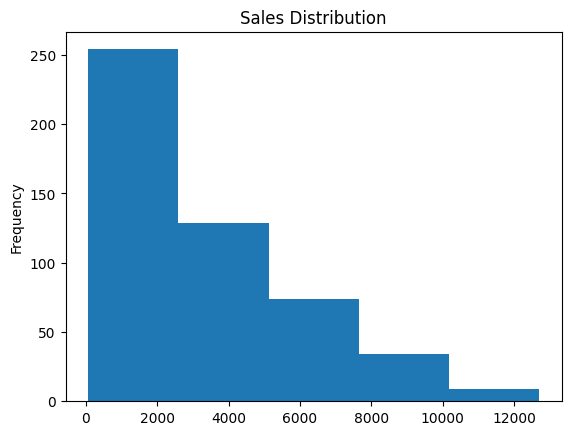

In [78]:
df_merged['sales'].plot(kind='hist', bins=5, title='Sales Distribution')

<Axes: xlabel='product'>

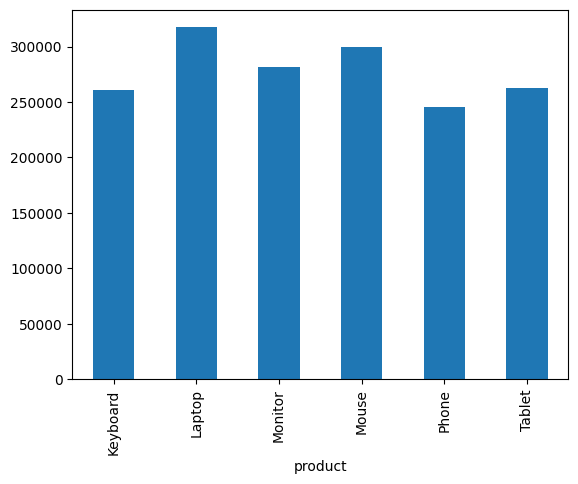

In [80]:
df_merged.groupby('product')['sales'].sum().plot(kind='bar')